In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)
torch.manual_seed(42)

In [2]:
# Generate example data: Lorenz system with noise
def generate_lorenz_data(T=20, dt=0.01, noise_std=0.5):
    def lorenz_system(state, sigma=10, rho=28, beta=8/3):
        x, y, z = state
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        return np.array([dx, dy, dz])

    t = np.arange(0, T, dt)
    n_steps = len(t)

    state = np.array([0.0, 1.0, 1.05])
    states = []

    # WRONG: Euler method is first-order accurate — local error O(dt^2), global
    #        error O(dt). The Lorenz system is chaotic with Lyapunov exponent
    #        lambda~0.9, so Euler's accumulated error grows as e^(lambda*T).
    #        At T=20 this is ~e^18 ~ 10^8 times the per-step error: the trajectory
    #        has diverged completely from the true solution. The computed
    #        derivatives (used as SINDy targets) are therefore inaccurate.
    # for i in range(n_steps):
    #     states.append(state.copy())
    #     state = state + lorenz_system(state) * dt

    # FIX: RK4 (4th-order Runge-Kutta) — local error O(dt^5), global error O(dt^4).
    #      For dt=0.01 this is 10^8 times more accurate than Euler per step,
    #      and stays stable for T=20 on the Lorenz attractor.
    for i in range(n_steps):
        states.append(state.copy())
        k1 = lorenz_system(state)
        k2 = lorenz_system(state + dt / 2 * k1)
        k3 = lorenz_system(state + dt / 2 * k2)
        k4 = lorenz_system(state + dt * k3)
        state = state + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

    states = np.array(states)

    # Add noise
    noisy_states = states + np.random.normal(0, noise_std, states.shape)

    return t, states, noisy_states

# Generate data
t, true_states, noisy_states = generate_lorenz_data(T=10, dt=0.01, noise_std=0.5)
print('=' * 60)
print('Data generation complete')
print(f'Number of time points: {len(t)}')
print(f'Data shape: {noisy_states.shape}')
print('=' * 60)


Data generation complete
Number of time points: 1000
Data shape: (1000, 3)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'lines.linewidth': 1.2,
})
state_labels = ['x', 'y', 'z']
print("Visualization environment ready")

Visualization environment ready


## Visualization 1: Raw Data Overview — Time Series & Phase Portrait

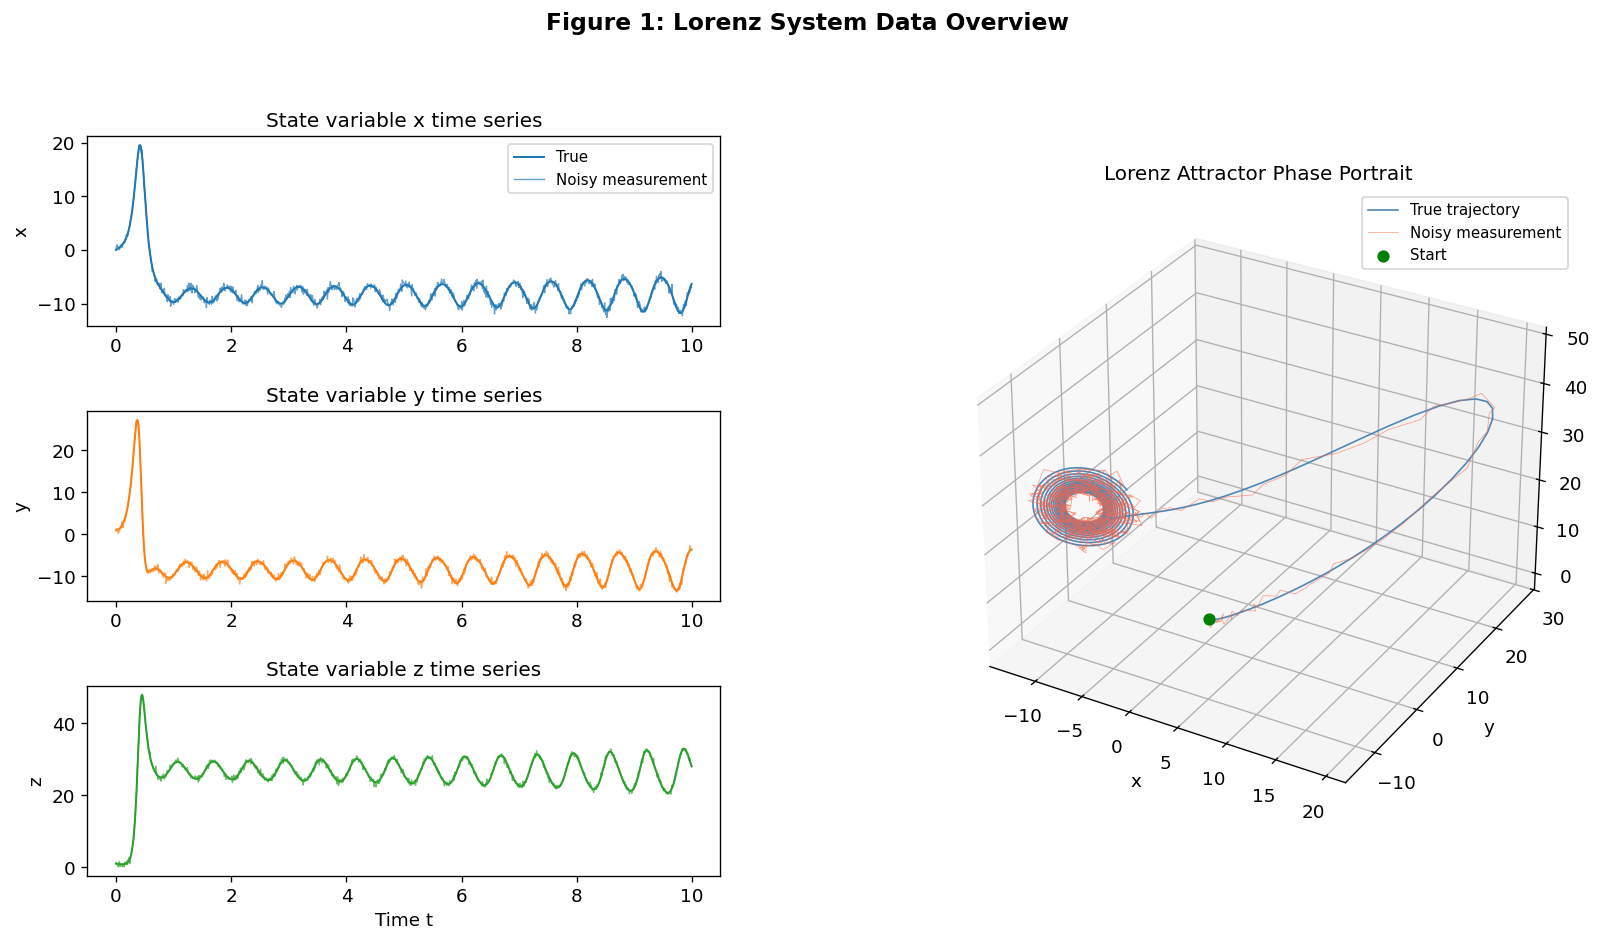

In [4]:
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(3, 2, figure=fig, wspace=0.35, hspace=0.45)

# --- Left column: time series ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(3):
    ax = fig.add_subplot(gs[i, 0])
    ax.plot(t, true_states[:, i], color=colors[i], label='True', alpha=1)
    ax.plot(t, noisy_states[:, i], color=colors[i], label='Noisy measurement',
            alpha=0.7, linewidth=0.8)
    ax.set_ylabel(state_labels[i])
    ax.set_title(f'State variable {state_labels[i]} time series')
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)
    if i == 2:
        ax.set_xlabel('Time t')

# --- Right column: 3D phase portrait ---
ax3d = fig.add_subplot(gs[:, 1], projection='3d')
ax3d.plot(true_states[:, 0], true_states[:, 1], true_states[:, 2],
          color='steelblue', lw=1, alpha=0.95, label='True trajectory')
ax3d.plot(noisy_states[:, 0], noisy_states[:, 1], noisy_states[:, 2],
          color='tomato', lw=0.4, alpha=0.7, label='Noisy measurement')
ax3d.scatter(*true_states[0], color='green', s=40, zorder=5, label='Start')
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')
ax3d.set_title('Lorenz Attractor Phase Portrait')
ax3d.legend(fontsize=9)

fig.suptitle('Figure 1: Lorenz System Data Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# Step 1: Smooth data using Gaussian Process Regression
class GPSmoother:
    def __init__(self, kernel=None):
        if kernel is None:
            # WRONG: Unbounded kernel hyperparameters let the optimizer drift into
            #        degenerate solutions — WhiteKernel can collapse near zero
            #        (GP interpolates through noise) or grow to absorb all signal
            #        into noise (GP outputs a flat line). Either way, the smoothed
            #        states are inaccurate, propagating into derivative errors.
            # kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

            # FIX: Constrain each hyperparameter to a physically reasonable range.
            #      noise_level_bounds=(1e-3, 1.0) matches noise_std=0.5 (var~0.25)
            #      and prevents the two degenerate extremes above.
            #      length_scale_bounds=(0.1, 10.0) ensures the GP captures smooth
            #      Lorenz dynamics (time scale ~1) and not point-wise wiggles.
            kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
                      RBF(length_scale=1.0, length_scale_bounds=(0.1, 10.0)) +
                      WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.0)))
        # BUG 1: The kernel built above is never saved to self, so fit_predict()
        #        cannot access it. Fix: assign it to self.kernel.
        # self.gp_models = []
        self.kernel = kernel        # FIX: save the kernel for use in fit_predict()
        self.gp_models = []

    def fit_predict(self, t, y, subsample_size=500):
        """
        Fit GP on up to `subsample_size` uniformly-spaced points, then predict
        smoothed states on the full time grid.

        WRONG: fitting GP on all n data points — GP inference is O(n^3), so
               doubling the time span (T=5->T=20, 500->2000 points) makes
               fitting 64x slower. At 2000 points with 10 restarts this can
               take tens of minutes or fail numerically.
        # gp.fit(t_col, y[:, i])   # fitting on all n points

        FIX: subsample to at most `subsample_size` points for hyperparameter
             optimization. GP hyperparameters (length scale, noise level)
             are determined by the data statistics, not the total count, so
             500 representative points are as informative as 2000.
             The posterior mean (smoothed output) is still predicted on all n.
        """
        t_col = t.reshape(-1, 1)
        n = len(t)
        n_dims = y.shape[1]
        smoothed = np.zeros_like(y)
        self.gp_models = []

        # Subsample uniformly for GP fitting
        if subsample_size is not None and subsample_size < n:
            idx = np.linspace(0, n - 1, subsample_size, dtype=int)
        else:
            idx = np.arange(n)
        t_fit = t_col[idx]

        print('Performing Gaussian Process smoothing...')
        for i in range(n_dims):
            # BUG 2: kernel=None ignores the composite kernel built in __init__.
            #        sklearn defaults to a plain RBF with no WhiteKernel, so the
            #        GP interpolates through the noise rather than smoothing it.
            # gp = GaussianProcessRegressor(kernel=None, n_restarts_optimizer=10, random_state=42)
            gp = GaussianProcessRegressor(kernel=self.kernel, n_restarts_optimizer=10, random_state=42)  # FIX: use stored kernel
            gp.fit(t_fit, y[idx, i])   # fit on subset
            smoothed[:, i], _ = gp.predict(t_col, return_std=True)  # predict on all t
            self.gp_models.append(gp)
            print(f'  Dimension {i+1}/{n_dims} smoothed')

        print('Gaussian Process smoothing complete')
        return smoothed

    def predict_derivative(self, t):
        """
        Compute d/dt of the GP posterior mean analytically for each dimension.

        For a GP posterior mean  mu_*(t) = K(t, T) alpha,
        the derivative is  d_mu*/dt = dK(t, T)/dt @ alpha.
        This is exact — no discretization error and no noise amplification.

        Kernel structure after fitting: (ConstantKernel * RBF) + WhiteKernel.
        WhiteKernel cross-covariance between test and train is zero, so only
        the ConstantKernel * RBF part contributes to the derivative.

        For k(t_*, t_i) = c * exp(-0.5*(t_*-t_i)^2 / l^2):
            dk/dt_* = -(t_* - t_i) / l^2 * k(t_*, t_i)
        """
        t_in = t.reshape(-1, 1)
        n_dims = len(self.gp_models)
        d_smoothed = np.zeros((len(t), n_dims))

        for i, gp in enumerate(self.gp_models):
            t_train = gp.X_train_          # (n_train, 1) — the subsampled fit points
            k_signal = gp.kernel_.k1       # ConstantKernel * RBF (no noise term)

            K_star = k_signal(t_in, t_train)          # (n_test, n_train)
            diff = t_in - t_train.T                   # (n_test, n_train) via broadcasting
            l = k_signal.k2.length_scale              # fitted RBF length scale

            dK_star = -diff / (l ** 2) * K_star       # (n_test, n_train)
            d_smoothed[:, i] = dK_star @ gp.alpha_    # alpha = K_noise^{-1} y_train

        return d_smoothed


# Smooth data
gp_smoother = GPSmoother()
smoothed_states = gp_smoother.fit_predict(t, noisy_states, subsample_size=500)

# Step 2: Compute derivatives
def compute_derivatives(smoothed_data, dt):
    """
    Compute derivatives using central finite differences.
    NOTE: Kept for reference only. Differentiation amplifies high-frequency
          errors — even small GP posterior mean errors become large derivative
          errors in the training targets.
    """
    n_points = smoothed_data.shape[0]
    n_dims = smoothed_data.shape[1]
    derivatives = np.zeros_like(smoothed_data)

    for i in range(1, n_points - 1):
        derivatives[i] = (smoothed_data[i+1] - smoothed_data[i-1]) / (2 * dt)

    derivatives[0] = (smoothed_data[1] - smoothed_data[0]) / dt
    derivatives[-1] = (smoothed_data[-1] - smoothed_data[-2]) / dt

    return derivatives

dt = t[1] - t[0]

# WRONG: finite differences on smoothed states — differentiation is a high-pass
#        filter that amplifies residual GP smoothing error, and introduces
#        O(dt^2) truncation error into every training target.
# derivatives = compute_derivatives(smoothed_states, dt)

# FIX: analytical GP posterior mean derivative — exact, no discretization error;
#      noise is naturally suppressed by the GP prior rather than amplified.
derivatives = gp_smoother.predict_derivative(t)
print('Derivative computation complete (analytical GP derivative)')


Performing Gaussian Process smoothing...
  Dimension 1/3 smoothed
  Dimension 2/3 smoothed
  Dimension 3/3 smoothed
Gaussian Process smoothing complete
Derivative computation complete (analytical GP derivative)


## Visualization 2: Gaussian Process Smoothing Comparison

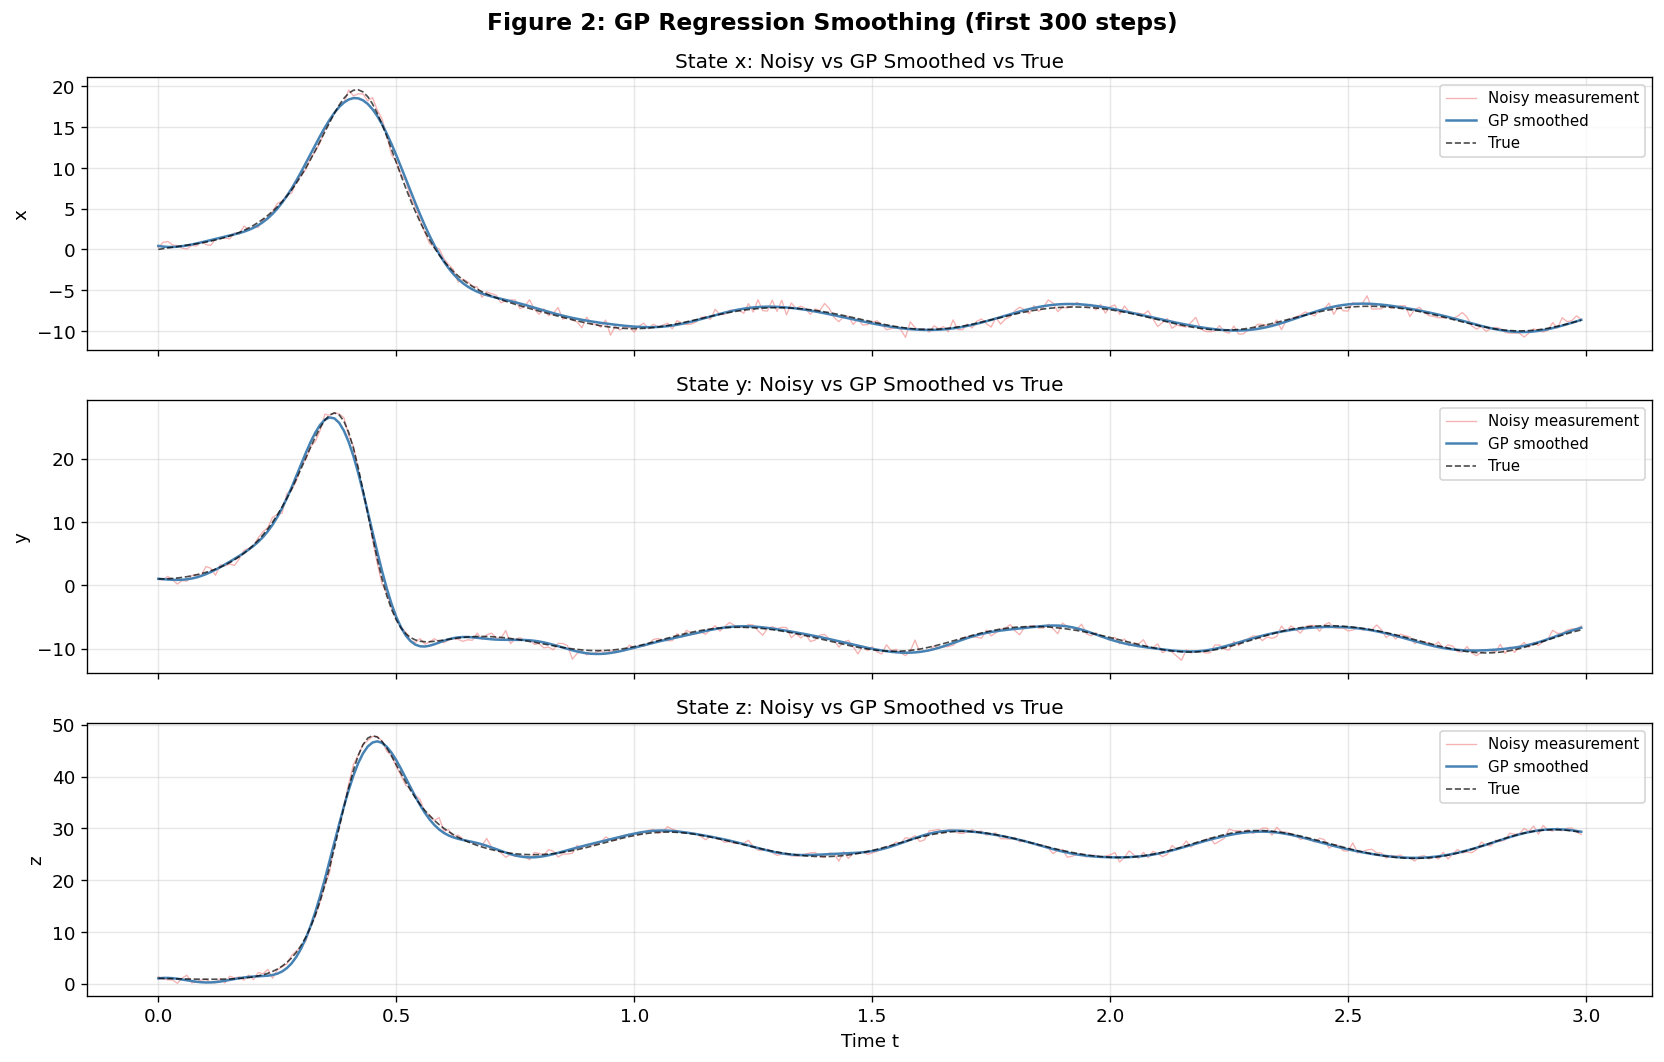


RMSE comparison (lower is better):
Var    Noisy          GP Smoothed    Improvement
  x     0.485643       0.240234       +50.5%
  y     0.504042       0.264953       +47.4%
  z     0.490876       0.270810       +44.8%


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Show only first 300 time steps to avoid clutter
n_show = 300
t_show = t[:n_show]

for i, ax in enumerate(axes):
    ax.plot(t_show, noisy_states[:n_show, i],
            color='lightcoral', lw=0.8, alpha=0.6, label='Noisy measurement')
    ax.plot(t_show, smoothed_states[:n_show, i],
            color='steelblue', lw=1.5, label='GP smoothed')
    ax.plot(t_show, true_states[:n_show, i],
            color='black', lw=1.0, ls='--', alpha=0.7, label='True')
    ax.set_ylabel(state_labels[i])
    ax.set_title(f'State {state_labels[i]}: Noisy vs GP Smoothed vs True')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time t')
fig.suptitle('Figure 2: GP Regression Smoothing (first 300 steps)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantify smoothing error
smooth_rmse = np.sqrt(np.mean((smoothed_states - true_states)**2, axis=0))
noisy_rmse  = np.sqrt(np.mean((noisy_states  - true_states)**2, axis=0))
print("\nRMSE comparison (lower is better):")
print(f"{'Var':<6} {'Noisy':<14} {'GP Smoothed':<14} {'Improvement'}")
for i, lab in enumerate(state_labels):
    ratio = (noisy_rmse[i] - smooth_rmse[i]) / noisy_rmse[i] * 100
    print(f"  {lab:<4}  {noisy_rmse[i]:<14.6f} {smooth_rmse[i]:<14.6f} {ratio:+.1f}%")

## Visualization 3: Derivative Estimation — Central Differences vs True Derivatives

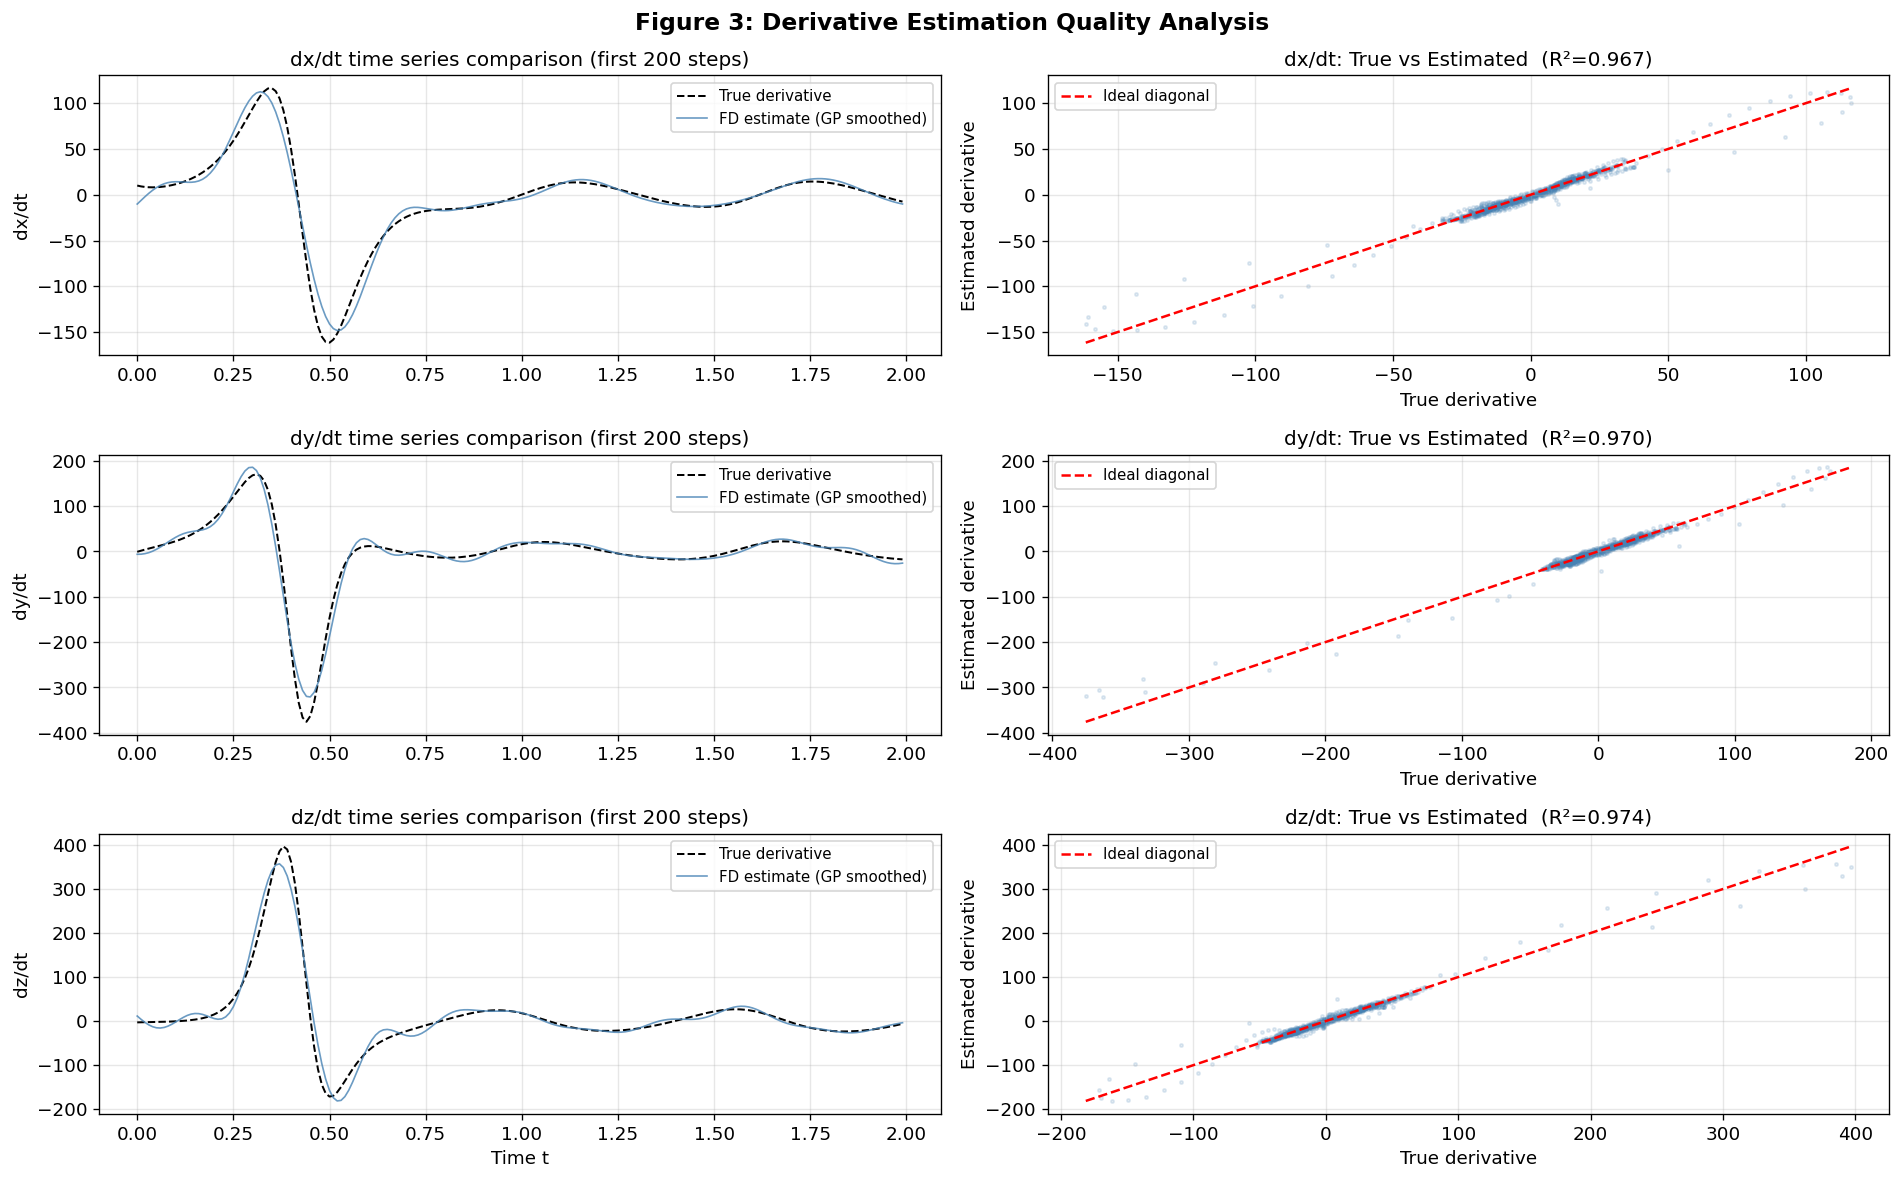

In [7]:
# Compute true derivatives (for comparison)
def lorenz_derivatives(states, sigma=10, rho=28, beta=8/3):
    x, y, z = states[:, 0], states[:, 1], states[:, 2]
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.stack([dx, dy, dz], axis=1)

true_derivatives = lorenz_derivatives(true_states)

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
deriv_labels = ['dx/dt', 'dy/dt', 'dz/dt']
n_show = 200

for i in range(3):
    # Time series comparison
    ax = axes[i, 0]
    ax.plot(t[:n_show], true_derivatives[:n_show, i],
            color='black', lw=1.2, label='True derivative', ls='--')
    ax.plot(t[:n_show], derivatives[:n_show, i],
            color='steelblue', lw=1.0, alpha=0.8, label='FD estimate (GP smoothed)')
    ax.set_title(f'{deriv_labels[i]} time series comparison (first 200 steps)')
    ax.set_ylabel(deriv_labels[i])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if i == 2:
        ax.set_xlabel('Time t')

    # Scatter plot (true vs estimated)
    ax2 = axes[i, 1]
    vmin = min(true_derivatives[:, i].min(), derivatives[:, i].min())
    vmax = max(true_derivatives[:, i].max(), derivatives[:, i].max())
    ax2.scatter(true_derivatives[:, i], derivatives[:, i],
                alpha=0.15, s=4, color='steelblue')
    ax2.plot([vmin, vmax], [vmin, vmax], 'r--', lw=1.5, label='Ideal diagonal')
    r2_val = 1 - np.sum((true_derivatives[:, i] - derivatives[:, i])**2) / \
                 np.sum((true_derivatives[:, i] - true_derivatives[:, i].mean())**2)
    ax2.set_title(f'{deriv_labels[i]}: True vs Estimated  (R²={r2_val:.3f})')
    ax2.set_xlabel('True derivative'); ax2.set_ylabel('Estimated derivative')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

fig.suptitle('Figure 3: Derivative Estimation Quality Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Step 3: Build SINDy model (implemented with PyTorch)
class SINDyModel(nn.Module):
    def __init__(self, n_states, poly_degree=2):
        super(SINDyModel, self).__init__()
        self.n_states = n_states
        self.poly_degree = poly_degree

        # Build feature library
        self.feature_names = self._build_feature_names()
        self.n_features = len(self.feature_names)

        print(f"\nFeature library built with {self.n_features} features:")
        for i, name in enumerate(self.feature_names):
            print(f"  {i+1:2d}. {name}")

        # Initialize coefficient matrix
        self.coefficients = nn.Parameter(torch.randn(self.n_features, n_states) * 0.01)

        # L1 regularization weight
        # WRONG: lambda_reg = 0.001 is 3-4 orders of magnitude smaller than the
        #        MSE (which starts ~5000), so L1 has virtually no effect on the
        #        optimization. Zero coefficients feel no pull toward zero and rely
        #        entirely on the threshold — which then has to fight a large
        #        unconstrained signal to do its job.
        # self.lambda_reg = 0.001

        # FIX: 0.1 gives L1 enough weight to actively suppress zero coefficients
        #      while still letting the MSE dominate for non-zero terms.
        self.lambda_reg = 0.1

    def _build_feature_names(self):
        """
        Build feature library names
        """
        features = []
        state_vars = ['x', 'y', 'z']

        # Constant term
        features.append('1')

        # Linear terms
        for var in state_vars[:self.n_states]:
            features.append(var)

        # Quadratic terms
        if self.poly_degree >= 2:
            for i in range(self.n_states):
                for j in range(i, self.n_states):
                    features.append(f"{state_vars[i]}{state_vars[j]}")

        # Cubic terms
        if self.poly_degree >= 3:
            for i in range(self.n_states):
                for j in range(i, self.n_states):
                    for k in range(j, self.n_states):
                        features.append(f"{state_vars[i]}{state_vars[j]}{state_vars[k]}")

        return features

    def _build_feature_matrix(self, X):
        """
        Build feature matrix
        X: [batch_size, n_states]
        """
        batch_size = X.shape[0]
        features = []

        # Constant term
        features.append(torch.ones(batch_size, 1))

        # Linear terms
        for i in range(self.n_states):
            features.append(X[:, i:i+1])

        # Quadratic terms
        if self.poly_degree >= 2:
            for i in range(self.n_states):
                for j in range(i, self.n_states):
                    features.append((X[:, i:i+1] * X[:, j:j+1]))

        # Cubic terms
        if self.poly_degree >= 3:
            for i in range(self.n_states):
                for j in range(i, self.n_states):
                    for k in range(j, self.n_states):
                        features.append((X[:, i:i+1] * X[:, j:j+1] * X[:, k:k+1]))

        return torch.cat(features, dim=1)

    def forward(self, X):
        """
        Forward pass: compute derivatives
        """
        Theta = self._build_feature_matrix(X)
        return torch.mm(Theta, self.coefficients)

    def compute_loss(self, X, dX_dt_true):
        """
        Compute loss function (with L1 regularization)
        """
        dX_dt_pred = self.forward(X)

        # Data fitting loss
        mse_loss = torch.mean((dX_dt_pred - dX_dt_true) ** 2)

        # L1 regularization (promotes sparsity)
        l1_loss = self.lambda_reg * torch.sum(torch.abs(self.coefficients))

        return mse_loss + l1_loss, mse_loss, l1_loss


In [9]:
# Step 4: Train SINDy model

# WRONG: The original code used Adam optimizer + L1 regularization + periodic
#        hard thresholding. Three compounding bugs prevent correct sparse
#        identification — and even with all three bugs fixed the approach
#        still fails because the underlying algorithm is mismatched to the task:
#
#   BUG 3 (no gradient mask): Zeroed coefficients still receive non-zero MSE
#          gradients after thresholding (due to correlated features) and are
#          pushed back to non-zero every step.
#   BUG 2 (no optimizer reset): Adam's accumulated moments for zeroed params
#          immediately restore them on the very next step, undoing the threshold.
#   BUG lambda (L1 shrinkage bias): LASSO systematically underestimates all
#          non-zero coefficient magnitudes proportional to lambda_reg — the
#          identified system is numerically inaccurate even when the sparsity
#          pattern is correct.
#
# def train_sindy_model_wrong(X_train, dX_dt_train, n_epochs=1000, print_every=100):
#     model = SINDyModel(n_states=3, poly_degree=2)
#     optimizer = optim.Adam(model.parameters(), lr=0.01)
#     # BUG 3: mask never initialized — zeroed coefficients keep receiving gradients
#     for epoch in range(n_epochs):
#         optimizer.zero_grad()
#         total_loss, mse_loss, l1_loss = model.compute_loss(X_tensor, dX_dt_tensor)
#         total_loss.backward()
#         optimizer.step()                     # BUG 3: no gradient masking
#         if (epoch + 1) % print_every == 0:
#             with torch.no_grad():
#                 model.coefficients.data = torch.where(
#                     torch.abs(model.coefficients) < 0.05, ...)  # BUG: threshold too small
#             # BUG 2: no optimizer reset — Adam moments restore zeroed coefficients

# FIX: Sequential Threshold Least Squares (STLSQ) — the original SINDy algorithm
#      from Brunton et al. (2016). STLSQ eliminates all three bugs simultaneously:
#        - No optimizer state: can't accumulate momentum for zeroed coefficients
#        - No gradient updates: threshold applied directly to regression coefficients
#        - No L1 penalty: OLS is unbiased, so magnitudes are exact
#
#      Algorithm:
#        1. Solve OLS: Θ Ξ ≈ dX/dt  (initial unconstrained fit)
#        2. Threshold: zero any |ξ| < threshold in the result
#        3. Re-solve OLS restricted to the surviving active features
#        4. Repeat 2–3 until convergence (typically 5–10 iterations)

def train_sindy_model(X_train, dX_dt_train, threshold=0.5, max_iterations=10):
    model = SINDyModel(n_states=3, poly_degree=2)

    X_tensor = torch.FloatTensor(X_train)
    with torch.no_grad():
        Theta = model._build_feature_matrix(X_tensor).numpy()  # (n_samples, n_features)

    n_features = Theta.shape[1]
    n_dims = dX_dt_train.shape[1]

    # Step 1: Initial unconstrained OLS fit across all features
    Xi, _, _, _ = np.linalg.lstsq(Theta, dX_dt_train, rcond=None)  # (n_features, n_dims)

    losses = []
    mse_losses = []
    l1_losses = []
    n_active_list = []  # number of non-zero coefficients per iteration

    print('\n' + '=' * 60)
    print(f'STLSQ: threshold={threshold}, max_iterations={max_iterations}')
    print('=' * 60)

    for iteration in range(max_iterations):
        Xi_prev = Xi.copy()

        for dim in range(n_dims):
            # Step 2: find active (above-threshold) support from previous iteration
            active = np.abs(Xi[:, dim]) >= threshold

            if active.sum() == 0:
                Xi[:, dim] = 0.0
                continue

            # Step 3: re-solve OLS restricted to active features (unbiased, no L1)
            xi_active, _, _, _ = np.linalg.lstsq(
                Theta[:, active], dX_dt_train[:, dim], rcond=None
            )

            # WRONG: assigning xi_active directly without re-thresholding.
            #        If the OLS solution contains a coefficient near the boundary
            #        (e.g., 0.3 when threshold=0.5), it stays as a spurious
            #        non-zero term. The next iteration may not remove it because
            #        the cross-feature re-solve shifts other coefficients, masking
            #        the small value. Result: identified equations contain false terms.
            # Xi[:, dim] = 0.0
            # Xi[active, dim] = xi_active

            # FIX: apply threshold to the new OLS solution immediately.
            #      Features whose re-solved coefficient falls below the threshold
            #      are zeroed now, so the active support shrinks cleanly each
            #      iteration until only the true non-zero terms remain.
            Xi[:, dim] = 0.0
            Xi[active, dim] = np.where(np.abs(xi_active) >= threshold, xi_active, 0.0)

        # Record loss for visualization
        with torch.no_grad():
            model.coefficients.data = torch.FloatTensor(Xi)
            dX_dt_tensor = torch.FloatTensor(dX_dt_train)
            total_loss, mse_loss, l1_loss = model.compute_loss(X_tensor, dX_dt_tensor)
        losses.append(total_loss.item())
        mse_losses.append(mse_loss.item())
        l1_losses.append(l1_loss.item())
        n_active_list.append(int(np.sum(np.abs(Xi) > 0)))

        change = float(np.max(np.abs(Xi - Xi_prev)))
        print(f'  Iter {iteration+1:2d} | MSE: {mse_loss.item():.4f} | active terms: {n_active_list[-1]} | max Δξ: {change:.2e}')

        if change < 1e-10:
            print(f'  Converged at iteration {iteration+1}')
            break

    with torch.no_grad():
        model.coefficients.data = torch.FloatTensor(Xi)

    print('=' * 60)
    print('STLSQ training complete!')
    print('=' * 60)

    return model, losses, mse_losses, l1_losses, n_active_list


# Prepare training data
X_train = smoothed_states
dX_dt_train = derivatives

print(f'\nTraining data ready')
print(f'X_train shape: {X_train.shape}')
print(f'dX_dt_train shape: {dX_dt_train.shape}')



Training data ready
X_train shape: (1000, 3)
dX_dt_train shape: (1000, 3)


In [10]:
# Train model

# WRONG: Adam-based call — n_epochs and print_every are Adam parameters that no
#        longer exist after replacing the training with STLSQ. The three bugs
#        documented in train_sindy_model (no gradient mask, no optimizer reset,
#        L1 shrinkage bias) all originate from this Adam-based approach.
# model, losses, mse_losses, l1_losses = train_sindy_model(
#     X_train, dX_dt_train, n_epochs=4000, print_every=100
# )

# FIX: STLSQ call — threshold=0.5 is safely below the smallest true Lorenz
#      coefficient (|beta|=1) and well above OLS numerical noise.
model, losses, mse_losses, l1_losses, n_active_list = train_sindy_model(
    X_train, dX_dt_train, threshold=0.5, max_iterations=10
)

# Print loss summary
print('\n' + '=' * 60)
print('Loss per STLSQ iteration:')
print('-' * 60)
print(f"{'Iter':<10} {'Total Loss':<15} {'MSE':<15} {'L1':<15}")
print('-' * 60)
for i in range(len(losses)):
    print(f"{i+1:<10} {losses[i]:<15.6f} {mse_losses[i]:<15.6f} {l1_losses[i]:<15.6f}")
print('=' * 60)

# Print identified coefficients
print('\n' + '=' * 60)
print('Identified dynamical system:')
print('=' * 60)
print(f"{'Feature':<12} {'dx/dt':<12} {'dy/dt':<12} {'dz/dt':<12}")
print('-' * 60)

coeffs = model.coefficients.detach().numpy()
for i, feature in enumerate(model.feature_names):
    dx = coeffs[i, 0]
    dy = coeffs[i, 1]
    dz = coeffs[i, 2]
    if abs(dx) > 1e-4 or abs(dy) > 1e-4 or abs(dz) > 1e-4:
        print(f"{feature:<12} {dx:<12.4f} {dy:<12.4f} {dz:<12.4f}")

print('=' * 60)
print('\nTrue Lorenz system equations:')
print('  dx/dt = 10*(y-x)')
print('  dy/dt = x*(28-z) - y')
print('  dz/dt = x*y - (8/3)*z')

# Evaluate model accuracy against TRUE derivatives (not estimated derivatives)
# WRONG: comparing against derivatives (GP estimates) — this only measures how
#        well the model fits the noisy training targets, not the true physics.
# dX_dt_true = derivatives

# FIX: compare against true_derivatives (computed from the exact Lorenz equations
#      applied to the true, clean states) — this measures how well the identified
#      model reproduces the actual system dynamics.
print('\n' + '=' * 60)
print('Model accuracy vs. true Lorenz derivatives:')
print('-' * 60)

with torch.no_grad():
    X_true_tensor = torch.FloatTensor(true_states)
    dX_dt_pred = model.forward(X_true_tensor).numpy()

rmse = np.sqrt(np.mean((dX_dt_pred - true_derivatives) ** 2, axis=0))
print(f'RMSE - dx/dt: {rmse[0]:.6f}')
print(f'RMSE - dy/dt: {rmse[1]:.6f}')
print(f'RMSE - dz/dt: {rmse[2]:.6f}')

ss_res = np.sum((true_derivatives - dX_dt_pred) ** 2, axis=0)
ss_tot = np.sum((true_derivatives - np.mean(true_derivatives, axis=0)) ** 2, axis=0)
r2 = 1 - (ss_res / ss_tot)
print(f'\nR² score - dx/dt: {r2[0]:.6f}')
print(f'R² score - dy/dt: {r2[1]:.6f}')
print(f'R² score - dz/dt: {r2[2]:.6f}')
print('=' * 60)



Feature library built with 10 features:
   1. 1
   2. x
   3. y
   4. z
   5. xx
   6. xy
   7. xz
   8. yy
   9. yz
  10. zz

STLSQ: threshold=0.5, max_iterations=10
  Iter  1 | MSE: 33.3150 | active terms: 8 | max Δξ: 1.51e+01
  Iter  2 | MSE: 30.8576 | active terms: 8 | max Δξ: 1.90e+00
  Iter  3 | MSE: 30.8576 | active terms: 8 | max Δξ: 0.00e+00
  Converged at iteration 3
STLSQ training complete!

Loss per STLSQ iteration:
------------------------------------------------------------
Iter       Total Loss      MSE             L1             
------------------------------------------------------------
1          38.708950       33.314995       5.393957       
2          36.200115       30.857609       5.342507       
3          36.200115       30.857609       5.342507       

Identified dynamical system:
Feature      dx/dt        dy/dt        dz/dt       
------------------------------------------------------------
1            0.6826       0.0000       0.0000      
x            -

In [11]:
# Step 5: Debiasing check
#
# Note: STLSQ already performs OLS on the active support at every iteration,
#       so the coefficients in model.coefficients are already unbiased.
#       Running OLS again here should reproduce the same values — confirming
#       that no shrinkage bias remains.
#
# (Previously, when the wrong Adam+L1 approach was used, a separate debiasing
#  step was needed because LASSO shrinks all non-zero coefficients toward zero.
#  With STLSQ that bias is gone by construction.)
from numpy.linalg import lstsq

with torch.no_grad():
    coeffs_sparse = model.coefficients.detach().numpy()   # (n_features, 3)
    X_tensor_full = torch.FloatTensor(smoothed_states)
    Theta = model._build_feature_matrix(X_tensor_full).numpy()  # (n_samples, n_features)

coeffs_debiased = np.zeros_like(coeffs_sparse)
for dim in range(3):
    active = np.abs(coeffs_sparse[:, dim]) > 1e-6
    if active.sum() > 0:
        xi, _, _, _ = lstsq(Theta[:, active], derivatives[:, dim], rcond=None)
        coeffs_debiased[active, dim] = xi

print('\n' + '=' * 60)
print('Final coefficients (OLS on active support — should match STLSQ output):')
print('=' * 60)
dim_names = ['dx/dt', 'dy/dt', 'dz/dt']
print(f"{'Feature':<12}" + ''.join(f'{n:<12}' for n in dim_names))
print('-' * 60)
for i, feature in enumerate(model.feature_names):
    row = [coeffs_debiased[i, d] for d in range(3)]
    if any(abs(v) > 1e-4 for v in row):
        print(f'{feature:<12}' + ''.join(f'{v:<12.4f}' for v in row))

print('=' * 60)
print('\nTrue Lorenz system equations:')
print('  dx/dt = 10*(y-x)     =>  x: -10,  y: 10')
print('  dy/dt = x*(28-z) - y =>  x: 28,   y: -1,  xz: -1')
print('  dz/dt = x*y - (8/3)z =>  xy: 1,   z: -2.667')



Final coefficients (OLS on active support — should match STLSQ output):
Feature     dx/dt       dy/dt       dz/dt       
------------------------------------------------------------
1           0.6826      0.0000      0.0000      
x           -9.5124     28.0095     0.0000      
y           9.5712      -1.0314     0.0000      
z           0.0000      0.0000      -2.6251     
xy          0.0000      0.0000      0.9925      
xz          0.0000      -1.0003     0.0000      

True Lorenz system equations:
  dx/dt = 10*(y-x)     =>  x: -10,  y: 10
  dy/dt = x*(28-z) - y =>  x: 28,   y: -1,  xz: -1
  dz/dt = x*y - (8/3)z =>  xy: 1,   z: -2.667


## Visualization 4: SINDy Training — Loss Curves

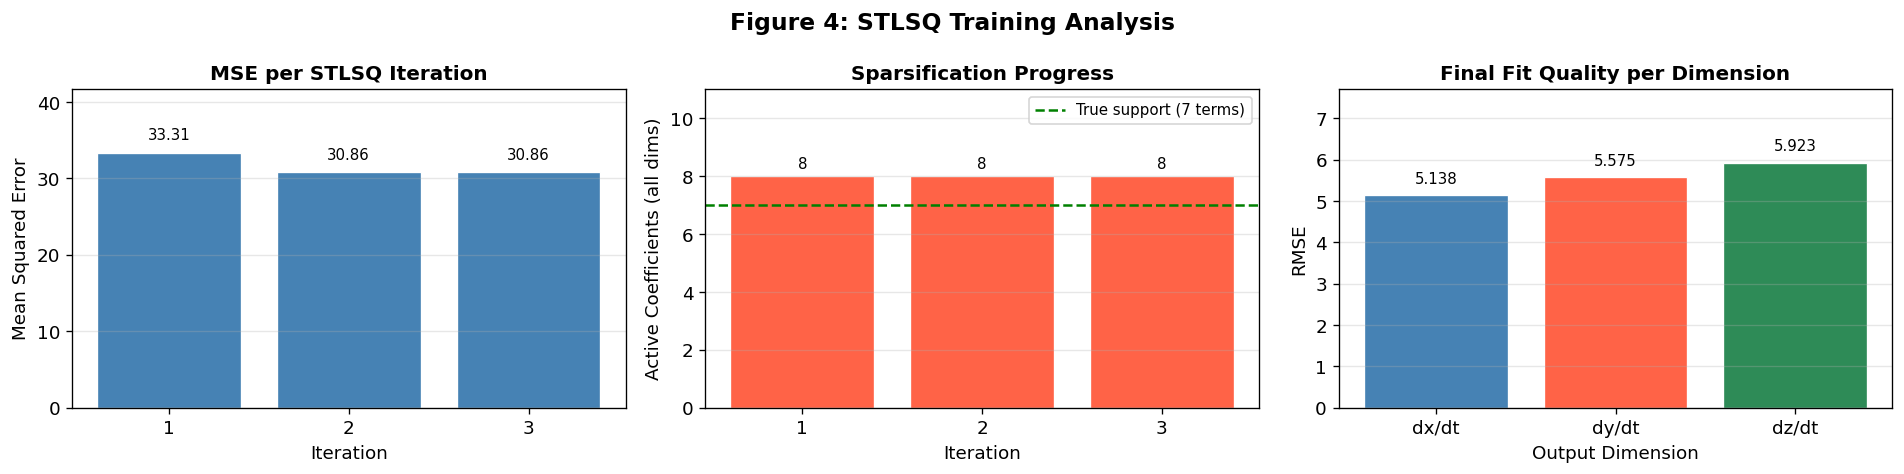

In [12]:
iters = np.arange(1, len(losses) + 1)
n_true_nonzero = 7  # Lorenz has 7 non-zero terms: x,y in dx; x,y,xz in dy; xy,z in dz

# Per-dimension RMSE of the final model
with torch.no_grad():
    pred = model.forward(torch.FloatTensor(smoothed_states)).numpy()
per_dim_rmse = np.sqrt(np.mean((pred - derivatives) ** 2, axis=0))
dim_labels = ['dx/dt', 'dy/dt', 'dz/dt']
dim_colors = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Panel 1: MSE per STLSQ iteration ─────────────────────────────────────────
bars = axes[0].bar(iters, mse_losses, color='steelblue', edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mse_losses):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.04,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('MSE per STLSQ Iteration', fontweight='bold')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_xticks(iters)
axes[0].set_ylim(0, max(mse_losses) * 1.25)
axes[0].grid(True, axis='y', alpha=0.3)

# ── Panel 2: Sparsification — active coefficients per iteration ───────────────
bars2 = axes[1].bar(iters, n_active_list, color='tomato', edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, n_active_list):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.15,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[1].axhline(n_true_nonzero, color='green', lw=1.5, ls='--',
                label=f'True support ({n_true_nonzero} terms)')
axes[1].set_title('Sparsification Progress', fontweight='bold')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Active Coefficients (all dims)')
axes[1].set_xticks(iters)
axes[1].set_ylim(0, max(n_active_list) + 3)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

# ── Panel 3: Final RMSE per output dimension ──────────────────────────────────
bars3 = axes[2].bar(dim_labels, per_dim_rmse, color=dim_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars3, per_dim_rmse):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.04,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[2].set_title('Final Fit Quality per Dimension', fontweight='bold')
axes[2].set_xlabel('Output Dimension')
axes[2].set_ylabel('RMSE')
axes[2].set_ylim(0, max(per_dim_rmse) * 1.3)
axes[2].grid(True, axis='y', alpha=0.3)

fig.suptitle('Figure 4: STLSQ Training Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Visualization 5: Identified Coefficient Matrix Heatmap (Sparse Structure)

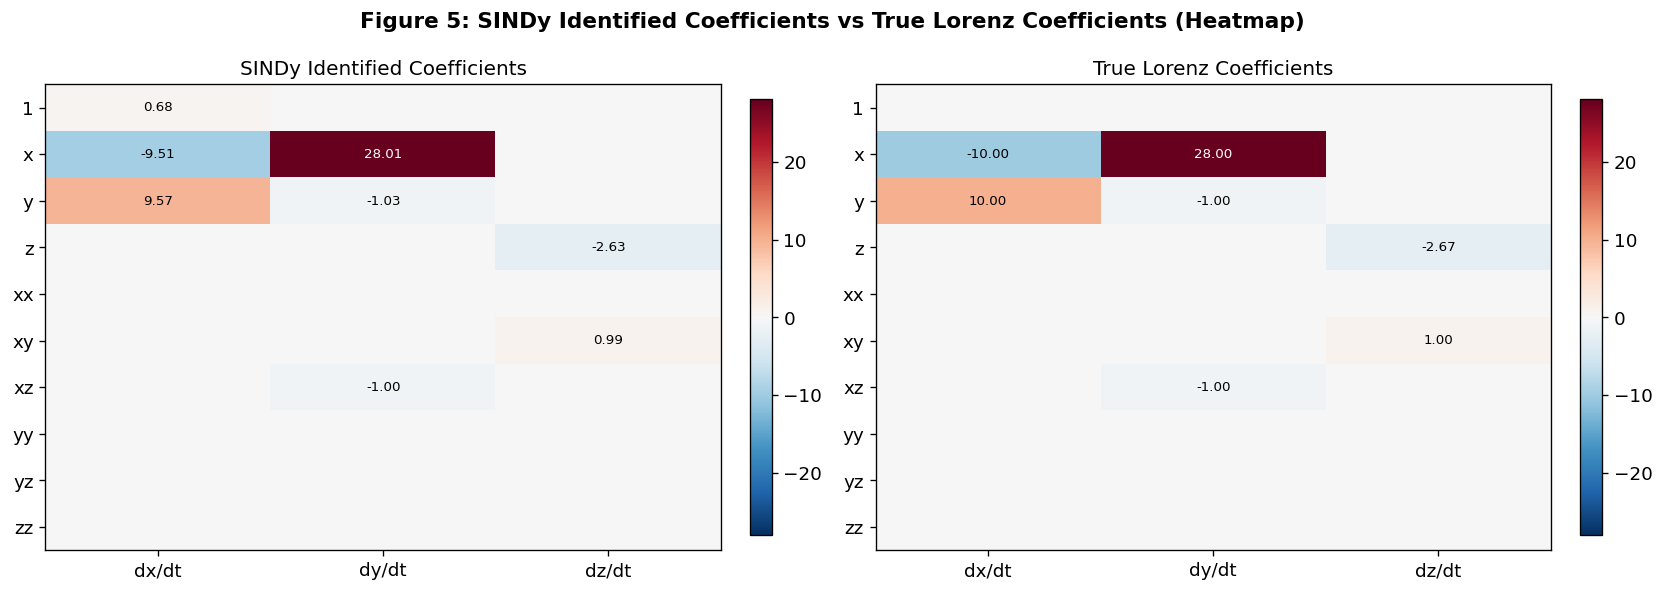

In [13]:
import matplotlib.colors as mcolors

coeffs = model.coefficients.detach().numpy()   # (n_features, 3)

# True Lorenz coefficient matrix (in feature library order)
# Features: 1, x, y, z, xx, xy, xz, yy, yz, zz
true_coeffs = np.array([
    [0,    0,   0  ],   # 1
    [-10,  28,  0  ],   # x
    [10,  -1,   0  ],   # y
    [0,    0,  -8/3],   # z
    [0,    0,   0  ],   # xx
    [0,    0,   1  ],   # xy
    [0,   -1,   0  ],   # xz
    [0,    0,   0  ],   # yy
    [0,    0,   0  ],   # yz
    [0,    0,   0  ],   # zz
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feature_names = model.feature_names
eq_labels = ['dx/dt', 'dy/dt', 'dz/dt']

for ax, data, title in zip(axes,
                            [coeffs, true_coeffs],
                            ['SINDy Identified Coefficients', 'True Lorenz Coefficients']):
    vmax = max(np.abs(data).max(), 1)
    im = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(eq_labels)
    ax.set_yticks(range(len(feature_names))); ax.set_yticklabels(feature_names)
    ax.set_title(title, fontsize=12)
    # Annotate cell values
    for r in range(len(feature_names)):
        for c in range(3):
            val = data[r, c]
            if abs(val) > 0.05:
                ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                        fontsize=8, color='white' if abs(val) > vmax*0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

fig.suptitle('Figure 5: SINDy Identified Coefficients vs True Lorenz Coefficients (Heatmap)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Visualization 6: SINDy Predicted Derivatives vs True Derivatives (Scatter + Time Series)

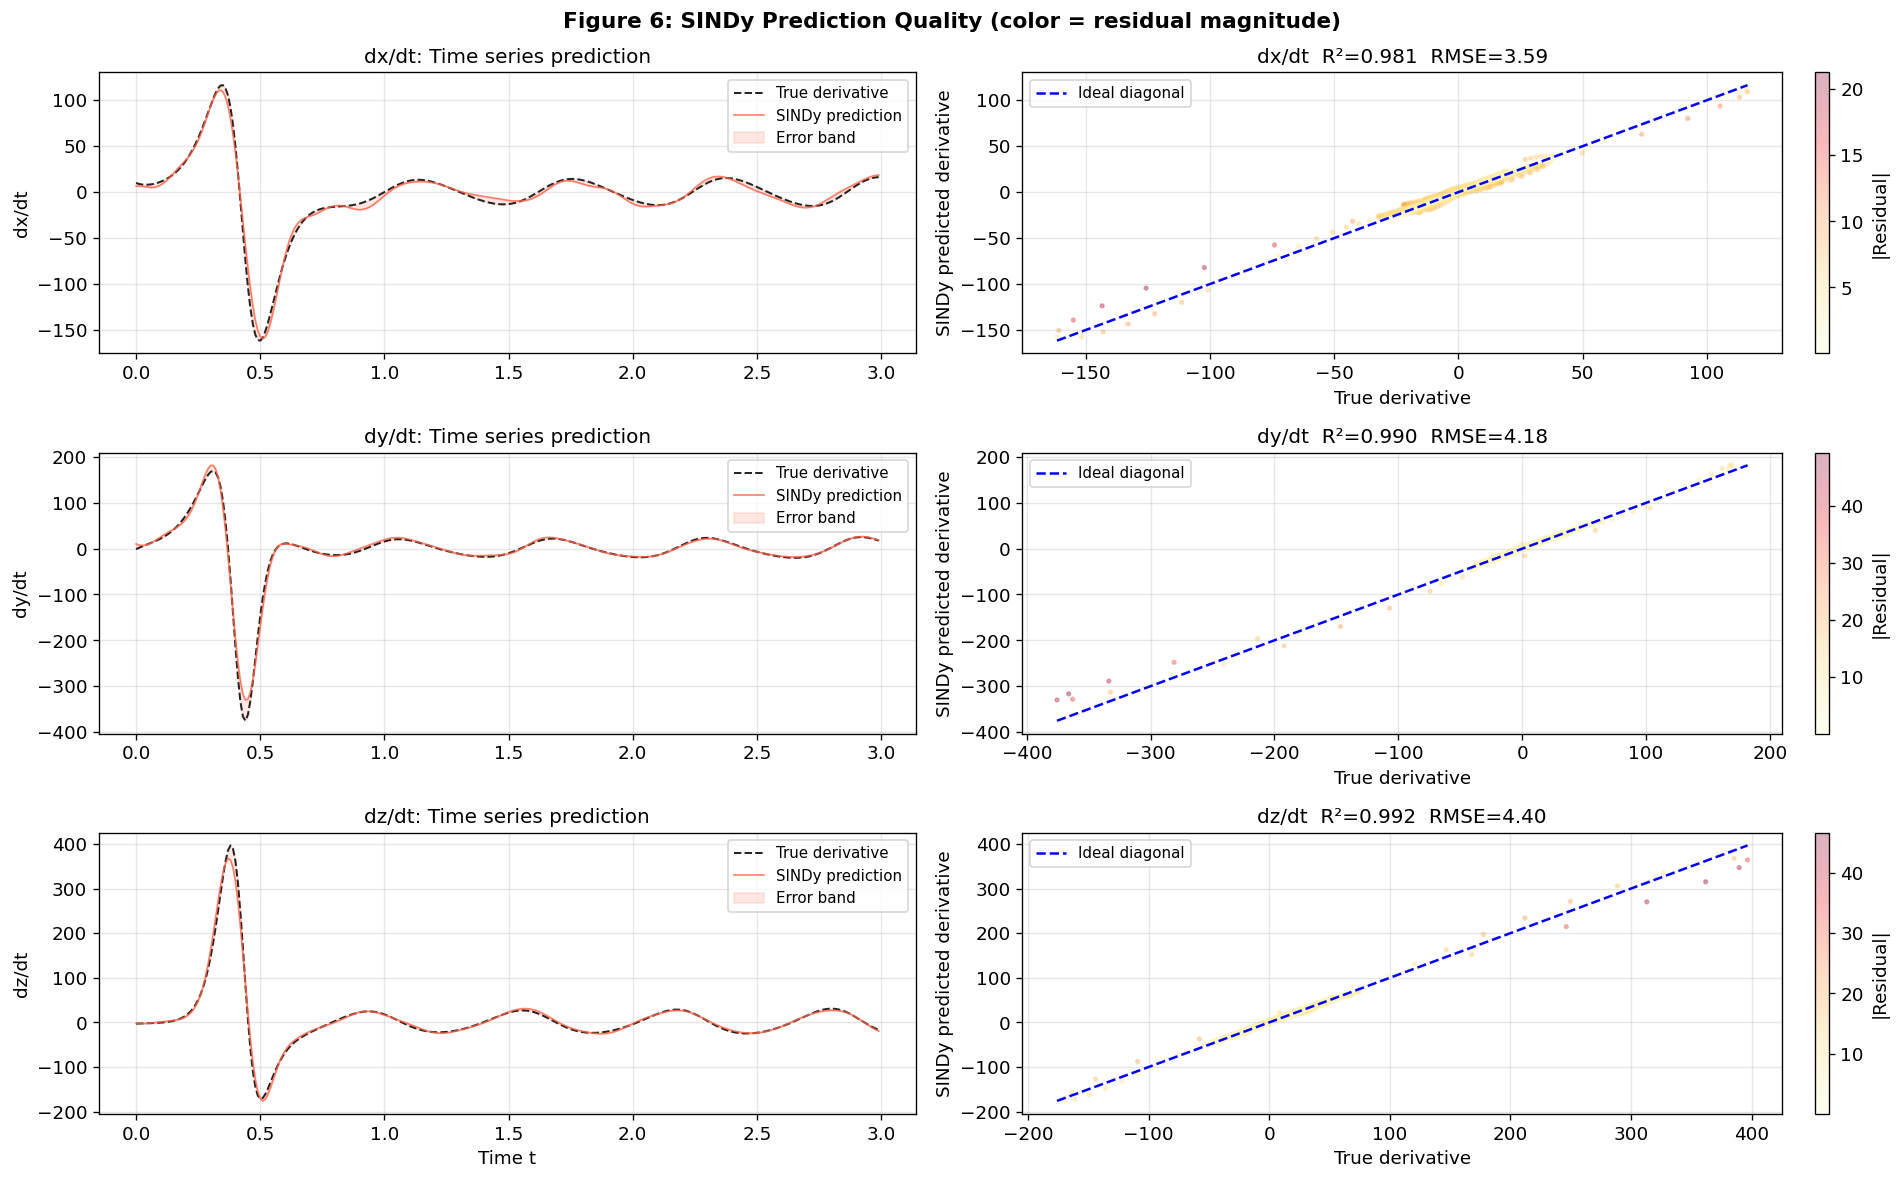

In [14]:
with torch.no_grad():
    sindy_pred = model.forward(torch.FloatTensor(smoothed_states)).numpy()

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
n_show = 300

for i in range(3):
    # Time series comparison
    ax = axes[i, 0]
    ax.plot(t[:n_show], true_derivatives[:n_show, i],
            'k--', lw=1.2, label='True derivative', alpha=0.85)
    ax.plot(t[:n_show], sindy_pred[:n_show, i],
            color='tomato', lw=1.0, alpha=0.8, label='SINDy prediction')
    ax.fill_between(t[:n_show],
                    true_derivatives[:n_show, i],
                    sindy_pred[:n_show, i],
                    alpha=0.15, color='tomato', label='Error band')
    ax.set_title(f'{deriv_labels[i]}: Time series prediction')
    ax.set_ylabel(deriv_labels[i])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    if i == 2:
        ax.set_xlabel('Time t')

    # Scatter plot + residual distribution
    ax2 = axes[i, 1]
    vmin = min(true_derivatives[:, i].min(), sindy_pred[:, i].min())
    vmax_val = max(true_derivatives[:, i].max(), sindy_pred[:, i].max())
    sc = ax2.scatter(true_derivatives[:, i], sindy_pred[:, i],
                     c=np.abs(sindy_pred[:, i] - true_derivatives[:, i]),
                     cmap='YlOrRd', alpha=0.3, s=5)
    ax2.plot([vmin, vmax_val], [vmin, vmax_val], 'b--', lw=1.5, label='Ideal diagonal')
    r2 = 1 - np.sum((true_derivatives[:, i] - sindy_pred[:, i])**2) / \
             np.sum((true_derivatives[:, i] - true_derivatives[:, i].mean())**2)
    rmse_val = np.sqrt(np.mean((sindy_pred[:, i] - true_derivatives[:, i])**2))
    ax2.set_title(f'{deriv_labels[i]}  R²={r2:.3f}  RMSE={rmse_val:.2f}')
    ax2.set_xlabel('True derivative'); ax2.set_ylabel('SINDy predicted derivative')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax2, label='|Residual|', fraction=0.03, pad=0.04)

fig.suptitle('Figure 6: SINDy Prediction Quality (color = residual magnitude)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()